# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?
7. What does it mean to say regularization “shrinks” coefficients, and why does that help reduce model variance?
8. Why is standardizing predictors especially important for LASSO and Ridge?
9. Why is the intercept usually not penalized?
10. As alpha goes to 0, what model do you recover? As alpha gets very large, what happens to the coefficients?
11. Why can regularization improve test performance even though it makes training error worse?

1. Adding a penalty discourages the model from using very large coefficients just to chase small improvements in training fit. It pushes the model toward simpler, more stable solutions that are less likely to overfit noise in the data.

2. Regularization lets us tune model complexity with the penalty strength. A small penalty gives low bias but higher variance; a large penalty shrinks coefficients more, which usually raises bias but lowers variance. By changing the penalty, we move along the bias-variance trade-off.

3. Ridge uses an L2 penalty, which shrinks coefficients toward zero but usually does not make them exactly zero. LASSO uses an L1 penalty, which can shrink some coefficients all the way to zero, so it also does variable selection. In practice, Ridge tends to keep all predictors with smaller weights, while LASSO tends to produce a sparser model.

4. We typically $z$-standardize predictors, by subtracting the mean and dividing by the standard deviation. This matters because the penalty acts on coefficient size, so predictors on larger scales would otherwise be penalized unfairly less or more. Scaling makes the penalty comparable across variables.

5. The penalty alpha is usually chosen with cross-validation. We fit the model over a grid of alpha values and pick the one that gives the best out-of-sample predictive performance, often the lowest cross-validated MSE.

6. No, when evaluating cross-validated MSE we usually use prediction error on the validation fold, not the penalized objective. The goal of cross-validation is to measure how well the model predicts new data, and future prediction error does not include a penalty term. The penalty is part of training, not part of the real-world loss we care about at evaluation time.

7. Saying regularization “shrinks” coefficients means it pulls the estimated coefficients closer to zero than they would be in ordinary least squares. Smaller coefficients make the model less sensitive to random quirks in the training sample, so predictions vary less across different samples and model variance goes down.

8. Standardizing predictors is important because the penalty is applied to coefficient size. If one predictor is measured on a much larger scale than another, its coefficient will naturally look smaller, so the penalty would treat the variables unevenly. Standardizing puts predictors on a common scale so the penalty is fair.

9. The intercept is usually not penalized because it just shifts the overall prediction level up or down rather than controlling the complexity of how predictors affect the outcome. Penalizing it would mainly distort the fit without helping much with overfitting.

10. As alpha -> 0, you recover the ordinary least squares solution. As alpha becomes very large, the coefficients are pushed strongly toward zero; in Ridge they get very small, and in LASSO many may become exactly zero.

11. Regularization can improve test performance because it trades a little more bias for a potentially large reduction in variance. Even if the model fits the training data a bit worse, it may generalize better by not chasing noise in the sample.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. PLot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

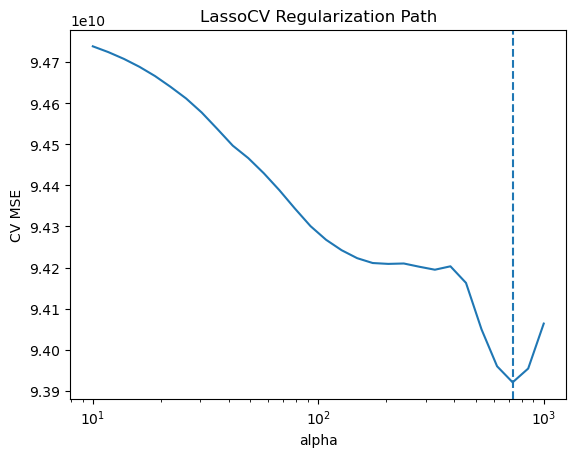

/home/trj/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.166e+11, tolerance: 6.675e+10
  model = cd_fast.enet_coordinate_descent_gram(
/home/trj/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.351e+11, tolerance: 6.675e+10
  model = cd_fast.enet_coordinate_descent_gram(
/home/trj/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. D

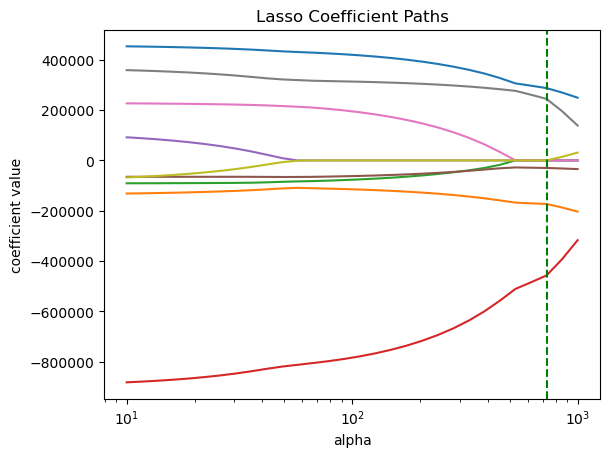

[0 1 3 5 7]
['Mileage_Run' 'Age' 'Mileage_Run Age' 'Mileage_Run^3' 'Mileage_Run Age^2']
Proportion of variables selected: 0.5555555555555556


,feature,linear_model,lasso
0,Mileage_Run,458071.119627,288335.957408
1,Age,-136698.072100,-172564.545030
2,Mileage_Run^2,-91643.120024,-0.000000
3,Mileage_Run Age,-898405.751356,-460528.046246
4,Age^2,113603.822348,-0.000000
5,Mileage_Run^3,-65144.896599,-29689.554572
6,Mileage_Run^2 Age,229021.676556,0.000000
7,Mileage_Run Age^2,368955.713359,246310.472510
8,Age^3,-84038.066146,0.000000


In [8]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LassoCV, lasso_path, LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv('./data/cars_hw.csv')

df['Age'] = np.max(df['Make_Year']) - df['Make_Year']
df.head()

# 1. Standardize features

y = df['Price']
X = df.loc[:, ['Mileage_Run', 'Age']]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(X.columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# 2. Run OLS for comparison
ols = LinearRegression()
ols = ols.fit(X_scaled, y)
ols_coef = ols.coef_

# 3. Use cross validation to fit the lasso model

alpha_grid = np.logspace(1,3,30)

model = LassoCV(alphas = alpha_grid,
                cv=20,
                max_iter=10000)
model = model.fit(X_scaled, y)

# 4. Plot the cross validated MSE by alpha

mean_mse = model.mse_path_.mean(axis=1)

plt.plot(model.alphas_, mean_mse)
plt.axvline(model.alpha_, linestyle="--")
plt.xscale("log")

plt.xlabel("alpha")
plt.ylabel("CV MSE")
plt.title("LassoCV Regularization Path")
plt.show()

# 5. Plot the coefficient path by alpha

alphas_path, coefs, _ = lasso_path(X_scaled, y, 
                                   alphas=alpha_grid )
for coef in coefs:
    plt.plot(alphas_path, coef)
plt.axvline(x=model.alpha_, color='green', linestyle='--')
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefficient value")
plt.title("Lasso Coefficient Paths")
plt.show()

# 6. Which features are selected? How many are selected?
selected = np.where(model.coef_ != 0)[0]
print( selected )
print( feature_names[selected] )
print(f'Proportion of variables selected: {len(selected)/len(feature_names)}')
pd.DataFrame({'feature':feature_names,
              'linear_model':ols_coef,
              'lasso':model.coef_})


It keeps the original variables, but eliminates a lot of the higher order powers, like `Age^3`. The positive coefficient on `Mileage_Run` might feel like a surprise, but `Mileage_Run^2` is missing and `Mileage_Run^3` is included, so the net effect of increasing mileage is probably a lower predict price overall. These kinds of relationships are hard to assess from looking at the coefficients alone.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

/home/trj/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.661e+00, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/home/trj/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.488e+00, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(


    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

/home/trj/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.314e+00, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/home/trj/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.079e+01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/home/trj/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. D

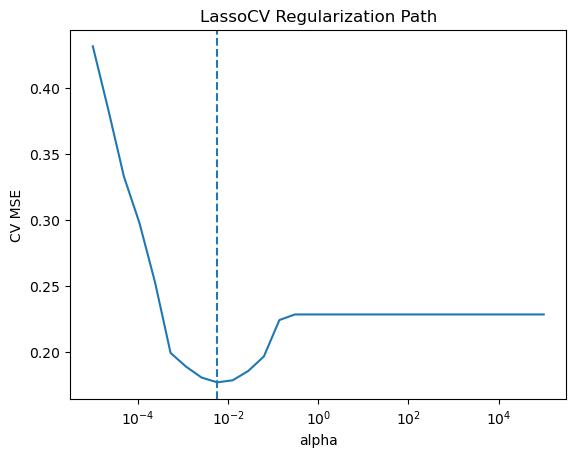

/home/trj/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.349e-01, tolerance: 9.600e-03
  model = cd_fast.enet_coordinate_descent_gram(
/home/trj/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.217e-02, tolerance: 9.600e-03
  model = cd_fast.enet_coordinate_descent_gram(
/home/trj/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. D

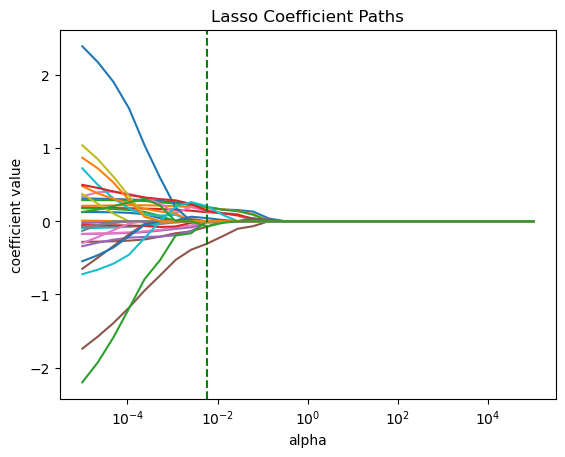

[ 0  1  2  7  8  9 15 16 23 29 30 32]
['anaemia' 'diabetes' 'high_blood_pressure' 'diabetes high_blood_pressure'
 'diabetes smoking' 'high_blood_pressure smoking' 'ejection_fraction'
 'serum_creatinine' 'age^3' 'ejection_fraction^3'
 'ejection_fraction^2 serum_creatinine' 'serum_creatinine^3']
Proportion of variables selected: 0.36363636363636365


,feature,linear_model,lasso
0,anaemia,-0.043420,0.014177
1,diabetes,-0.149472,0.000609
2,high_blood_pressure,-0.073480,0.013609
3,smoking,-0.168209,-0.000000
4,anaemia diabetes,0.137585,0.000000
5,anaemia high_blood_pressure,0.040708,0.000000
6,anaemia smoking,0.139289,0.000000
7,diabetes high_blood_pressure,0.282831,0.053965
8,diabetes smoking,0.337922,0.003466
9,high_blood_pressure smoking,0.213817,0.017803


In [9]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LassoCV, lasso_path, LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv('./data/heart_failure/heart_failure_clinical_records_dataset.csv')
print(df.head())

# 1. Standardize data and feature engineer
poly = PolynomialFeatures(degree=3, 
                          include_bias=False, 
                          interaction_only=True)
categorical_vars = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']
ohc = df.loc[:,categorical_vars]
ohc_poly = poly.fit_transform(ohc)
categorical_names = poly.get_feature_names_out(ohc.columns)

poly = PolynomialFeatures(degree=3, 
                          include_bias=False)
numeric_vars = ['age', 'ejection_fraction', 'serum_creatinine']
X_num = df.loc[:, numeric_vars]
X_poly = poly.fit_transform(X_num)
numeric_names = poly.get_feature_names_out(X_num.columns)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

X = np.concatenate([ohc_poly, X_scaled], axis = 1)
names = np.concatenate([categorical_names, numeric_names])
y = df['DEATH_EVENT']

# 2. OLS
ols = LinearRegression()
ols = ols.fit(X, y)
ols_coef = ols.coef_

# 3. LASSO fit
alpha_grid = np.logspace(-5,5,30)
model = LassoCV(alphas = alpha_grid,
                cv=20,
                max_iter=10000)
model = model.fit(X, y)

# 4. MSE by alpha
mean_mse = model.mse_path_.mean(axis=1)
plt.plot(model.alphas_, mean_mse)
plt.axvline(model.alpha_, linestyle="--")
plt.xscale("log")

plt.xlabel("alpha")
plt.ylabel("CV MSE")
plt.title("LassoCV Regularization Path")
plt.show()

# 5. Coefficient paths
alphas_path, coefs, _ = lasso_path(X, y, 
                                   alphas=alpha_grid )
for coef in coefs:
    plt.plot(alphas_path, coef)
plt.axvline(x=model.alpha_, color='green', linestyle='--')
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefficient value")
plt.title("Lasso Coefficient Paths")
plt.show()

# 6. Which are selected?
selected = np.where(model.coef_ != 0)[0]
print( selected )
print( names[selected] )
print(f'Proportion of variables selected: {len(selected)/len(names)}')

pd.DataFrame({'feature':names,
              'linear_model':ols_coef,
              'lasso':model.coef_})


Originally, anaemia, diabetes, high_blood_pressure, and smoking all had negative coefficients, suggesting that they reduced the probability of a heart attack. After regularization, the coefficients for these variables either go positive or zero. High blood pressure raises the risk by 1.3%, and adding smoking increases the risk to 3%. This all makes a lot more sense, in terms of intuition and prediction. So the large feature space somewhat overwhelmed the linear model, but the lasso makes the results make a bit more sense.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

1. The objective function becomes
$$
\frac{1}{n} \sum_{i=1}^{n} (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)^2 + \alpha b_1^2.
$$

2. The first order conditions are
\begin{alignat*}{2}
\frac{-2}{n} \sum_{i=1}^{n} (\tilde{y}_i - b_0 - b_1 \tilde{x}_i) &=& 0\\
\frac{-2}{n} \sum_{i=1}^{n} (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)\tilde{x}_i + 2 \alpha b_1 &=& 0
\end{alignat*}
The first equation implies that $b_0^* = 0$, since
$$
\frac{1}{n} \sum_{i=1}^{n} \tilde{y}_i - n b_0 - b_1 \frac{1}{n} \sum_{i=1}^{n}\tilde{x}_i = 0
$$
implies $\hat{b}_0 = 0$. Solving the second equation using that $\hat{b}_0 = 0$, the second equation implies that
$$
\hat{b}_1 = \dfrac{\frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2+\alpha}.
$$

3. As $\alpha$ goes up, the slope coefficient shrinks (this is why regularization is also called "shrinkage").

4. This is a lot harder. The CHALLENGE is that $|x|$ is not differentiable at zero, so the "derivative" of $|x|$ is
$$
|x|' = \begin{cases}
-1, & x < 0 \\
\text{undefined}, & x = 0 \\
+1, & x>0.
\end{cases}
$$
This makes solving the equations much more difficult. That's a totally sufficient answer.

For a bit more detail, we can follow the same steps as for Ridge, which yield a slope coefficient of 
$$
\hat{b}_1 = \dfrac{\frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}) - \frac{\alpha}{2} |\hat{b}_1|'}{\frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2}.
$$
But it's a conceptual challenge to make sense of this, because $|b_1|'$ depends on $\hat{b}_1$. If this expression: 
$$
\dfrac{\frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}) - \frac{\alpha}{2} }{\frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2}
$$
is strictly positive, then it can be $\hat{b}_1$ without contradiction and we are done; similarly, if this expression 
$$
\dfrac{\frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}) + \frac{\alpha}{2} }{\frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2}
$$
is strictly negative, then it can be $\hat{b}_1$ without contradiction and we are done. However, if the sign of $\hat{b}_1$ keeps "flipping back and forth" because $|\hat{b}_1|'$ is jumping back and forth from -1 to +1, then we can't solve for $\hat{b}_1$. In that case, we reach a contradiction, and the solution is then to set $\hat{b}_1 =0$. This is how the coefficients get "zeroed out" in the LASSO, typically using a technique called LARS (Least Angle Regression).
